# Otimização do MLP em Lotes para Predição de Preços de Carros

Este notebook apresenta um estudo comparativo completo com o objetivo de otimizar o desempenho do classificador regressivo **MLP Lotes** (Multi-Layer Perceptron treinado com mini-lotes, momentum e taxa de decaimento do aprendizado).

### Regra de Divisão dos Dados:
- **800 primeiras linhas** para treinamento do modelo.
- **200 linhas seguintes** para teste e avaliação da acurácia.

### Objetivo:
Atingir uma acurácia mais elevada (porcentagem de erros menores ou iguais a 10% em relação ao preço real) testando diferentes topologias de rede e conjuntos de atributos de entrada (incluindo atributos categóricos como Marca, Modelo e Transmissão).

In [1]:
# ==================================================================
# BLOCO 1: Importações e Configuração da Lista Global de Resultados
# ==================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import display

resultados_gerais = []

In [2]:
# ==================================================================
# BLOCO 2: Carregamento do Dataset e Mapeamento Categórico Determinístico
# ==================================================================
df = pd.read_csv('car_price_dataset.csv')
df_limpo = df.dropna()

# Mapeando variáveis categóricas manualmente
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Electric': 2, 'Hybrid': 3}
transmission_mapping = {'Manual': 0, 'Automatic': 1, 'Semi-Automatic': 2}

brand_unique = sorted(df_limpo['Brand'].unique())
brand_mapping = {b: i for i, b in enumerate(brand_unique)}

model_unique = sorted(df_limpo['Model'].unique())
model_mapping = {m: i for i, m in enumerate(model_unique)}

df_limpo['Fuel_Type'] = df_limpo['Fuel_Type'].map(fuel_mapping)
df_limpo['Transmission'] = df_limpo['Transmission'].map(transmission_mapping)
df_limpo['Brand'] = df_limpo['Brand'].map(brand_mapping)
df_limpo['Model'] = df_limpo['Model'].map(model_mapping)

print(f"Dataset pronto! Formato: {df_limpo.shape}")
display(df_limpo.head())

Dataset pronto! Formato: (10000, 10)


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,6,24,2020,4.2,1,0,289944,3,5,8501
1,2,19,2012,2.0,3,1,5356,2,3,12092
2,7,16,2020,4.2,1,1,231440,4,2,11171
3,0,22,2023,2.0,2,0,160971,2,1,11780
4,9,17,2003,2.6,3,2,286618,3,3,2867


In [3]:
# ==================================================================
# BLOCO 3: Classe RedeNeuralNumpy com Suporte a Mini-lotes e Momentum
# ==================================================================
class RedeNeuralNumpy:
    def __init__(self, topologia, taxa_aprendizado=0.005, momentum=0.9):
        self.topologia = topologia
        self.lr_inicial = taxa_aprendizado
        self.lr = taxa_aprendizado
        self.momentum = momentum
        self.pesos = []
        self.vieses = []
        self.v_pesos = []
        self.v_vieses = []
        
        # Inicialização He para os pesos e zera os vieses
        for i in range(len(topologia) - 1):
            W = np.random.randn(topologia[i], topologia[i+1]) * np.sqrt(2. / topologia[i])
            b = np.zeros((1, topologia[i+1]))
            self.pesos.append(W)
            self.vieses.append(b)
            self.v_pesos.append(np.zeros_like(W))
            self.v_vieses.append(np.zeros_like(b))

    def _relu(self, z):
        return np.maximum(0, z)
    
    def _derivada_relu(self, a):
        return (a > 0).astype(float)

    def forward(self, X):
        ativacoes = [X]
        for i in range(len(self.pesos) - 1):
            z = np.dot(ativacoes[-1], self.pesos[i]) + self.vieses[i]
            a = self._relu(z)
            ativacoes.append(a)
            
        # Camada de saída linear (regressão contínua de preço)
        z_saida = np.dot(ativacoes[-1], self.pesos[-1]) + self.vieses[-1]
        ativacoes.append(z_saida)
        return ativacoes

    def backward(self, ativacoes, y_verdadeiro):
        m = y_verdadeiro.shape[0]
        delta = (ativacoes[-1] - y_verdadeiro)
        
        grad_pesos = []
        grad_vieses = []
        
        grad_W = np.dot(ativacoes[-2].T, delta) / m
        grad_b = np.sum(delta, axis=0, keepdims=True) / m
        grad_pesos.append(grad_W)
        grad_vieses.append(grad_b)
        
        # Backpropagation das camadas ocultas
        for i in range(len(self.pesos) - 2, -1, -1):
            delta = np.dot(delta, self.pesos[i+1].T) * self._derivada_relu(ativacoes[i+1])
            grad_W = np.dot(ativacoes[i].T, delta) / m
            grad_b = np.sum(delta, axis=0, keepdims=True) / m
            grad_pesos.insert(0, grad_W)
            grad_vieses.insert(0, grad_b)
            
        # Atualização dos parâmetros com momentum
        for i in range(len(self.pesos)):
            self.v_pesos[i] = (self.momentum * self.v_pesos[i]) + (self.lr * grad_pesos[i])
            self.v_vieses[i] = (self.momentum * self.v_vieses[i]) + (self.lr * grad_vieses[i])
            self.pesos[i] -= self.v_pesos[i]
            self.vieses[i] -= self.v_vieses[i]
            
    def treinar(self, X, y, epocas, tamanho_lote=32):
        historico_mse = []
        m_total = X.shape[0]
        
        for epoca in range(epocas):
            # Decaimento suave da taxa de aprendizado a cada época
            self.lr = self.lr_inicial * (0.95 ** (epoca / 500))
            
            # Embaralhar dados a cada época
            indices = np.random.permutation(m_total)
            X_embaralhado = X[indices]
            y_embaralhado = y[indices]
            
            # Treinamento por mini-lotes (Lotes)
            for i in range(0, m_total, tamanho_lote):
                X_lote = X_embaralhado[i : i + tamanho_lote]
                y_lote = y_embaralhado[i : i + tamanho_lote]
                ativacoes = self.forward(X_lote)
                self.backward(ativacoes, y_lote)
                
            # Monitorar perda de treino ao final de cada época
            ativacoes_totais = self.forward(X)
            mse = np.mean((ativacoes_totais[-1] - y) ** 2)
            historico_mse.append(mse)
            
        return historico_mse

In [4]:
# ==================================================================
# BLOCO 4: Função para Padronizar a Execução dos Experimentos
# ==================================================================
def rodar_experimento(nome_modelo, features_colunas, topologia, epocas=1500, batch_size=32, lr=0.005):
    # Extração de dados da amostra de 1000 carros do df
    X = df_limpo[features_colunas].values[:1000]
    y = df_limpo['Price'].values[:1000].reshape(-1, 1)

    # Normalização Z-Score com NumPy
    medias = np.mean(X, axis=0)
    desvios = np.std(X, axis=0)
    desvios[desvios == 0] = 1e-8
    X_norm = (X - medias) / desvios

    media_y = np.mean(y)
    desvio_y = np.std(y)
    y_norm = (y - media_y) / desvio_y

    # Divisão determinística rigorosa: 800 primeiras linhas para treino e 200 seguintes para teste
    X_treino, X_teste = X_norm[:800], X_norm[800:1000]
    y_treino, y_teste = y_norm[:800], y_norm[800:1000]
    y_teste_reais = y[800:1000]

    np.random.seed(42)
    t0 = time.time()
    modelo = RedeNeuralNumpy(topologia, taxa_aprendizado=lr, momentum=0.9)
    historico = modelo.treinar(X_treino, y_treino, epocas, batch_size)
    tempo_treino = time.time() - t0

    # Predição e desnormalização para escala real de moeda
    pred = modelo.forward(X_teste)[-1]
    pred_reais = pred * desvio_y + media_y
    erros_reais = y_teste_reais - pred_reais
    # Cálculo das métricas comparativas
    eqm_teste_real = np.mean(erros_reais**2)
    mape = np.mean(np.abs(erros_reais / y_teste_reais))
    # Acurácia de regressão definida como erro menor ou igual a 10% do valor real
    acuracia = np.mean(np.abs(erros_reais / y_teste_reais) <= 0.10) * 100
    precisao = max(0.0, (1.0 - mape) * 100)

    # Contar as camadas ocultas
    qtd_camadas_ocultas = len(topologia) - 2
    camadas_texto = f"{qtd_camadas_ocultas} camada(s)" if qtd_camadas_ocultas > 0 else "0 camadas"
    neuronios_texto = ", ".join(map(str, topologia[1:-1])) + " neurônios" if qtd_camadas_ocultas > 0 else "Sem neurônios ocultos"

    resultados_gerais.append({
        'Modelo': nome_modelo,
        'Épocas': epocas,
        'Camadas Ocultas': camadas_texto,
        'Neurônios (Ocultos)': neuronios_texto,
        'Acurácia (%)': float(acuracia),
        'Precisão (%)': float(precisao),
        'EQM (Real)': float(eqm_teste_real),
        'Tempo de Treino (s)': float(tempo_treino)
    })
    
    print(f"-> Treinado: {nome_modelo} | Tempo: {tempo_treino:.4f}s | Acurácia: {acuracia:.2f}% | Precisão: {precisao:.2f}%")
    return historico

In [5]:
# ==================================================================
# BLOCO 5: Executando os Experimentos com Diferentes Atributos e Topologias
# ==================================================================
features_A = ['Year', 'Engine_Size', 'Fuel_Type', 'Mileage', 'Owner_Count', 'Doors']
features_B = ['Brand', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Owner_Count', 'Doors']
features_C = ['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Owner_Count', 'Doors']

historicos = {}

print("Treinando modelos do GRUPO A (6 atributos originais)... ")
historicos['MLP Lotes Set A (Rasa: [6, 5, 1])'] = rodar_experimento('MLP Lotes Set A (Rasa)', features_A, [6, 5, 1])
historicos['MLP Lotes Set A (Base: [6, 15, 1])'] = rodar_experimento('MLP Lotes Set A (Base)', features_A, [6, 15, 1])
historicos['MLP Lotes Set A (Média: [6, 16, 8, 1])'] = rodar_experimento('MLP Lotes Set A (Média)', features_A, [6, 16, 8, 1])

print("\nTreinando modelos do GRUPO B (8 atributos - incluindo Marca e Transmissão)... ")
historicos['MLP Lotes Set B (Rasa: [8, 5, 1])'] = rodar_experimento('MLP Lotes Set B (Rasa)', features_B, [8, 5, 1])
historicos['MLP Lotes Set B (Base: [8, 15, 1])'] = rodar_experimento('MLP Lotes Set B (Base)', features_B, [8, 15, 1])
historicos['MLP Lotes Set B (Média: [8, 16, 8, 1])'] = rodar_experimento('MLP Lotes Set B (Média)', features_B, [8, 16, 8, 1])
historicos['MLP Lotes Set B (Profunda: [8, 32, 16, 8, 1])'] = rodar_experimento('MLP Lotes Set B (Profunda)', features_B, [8, 32, 16, 8, 1])

print("\nTreinando modelos do GRUPO C (9 atributos - incluindo Marca, Modelo e Transmissão)... ")
historicos['MLP Lotes Set C (Rasa: [9, 5, 1])'] = rodar_experimento('MLP Lotes Set C (Rasa)', features_C, [9, 5, 1])
historicos['MLP Lotes Set C (Base: [9, 15, 1])'] = rodar_experimento('MLP Lotes Set C (Base)', features_C, [9, 15, 1])
historicos['MLP Lotes Set C (Média: [9, 16, 8, 1])'] = rodar_experimento('MLP Lotes Set C (Média)', features_C, [9, 16, 8, 1])
historicos['MLP Lotes Set C (Profunda: [9, 32, 16, 8, 1])'] = rodar_experimento('MLP Lotes Set C (Profunda)', features_C, [9, 32, 16, 8, 1])

Treinando modelos do GRUPO A (6 atributos originais)... 


-> Treinado: MLP Lotes Set A (Rasa) | Tempo: 13.4063s | Acurácia: 73.50% | Precisão: 91.66%


-> Treinado: MLP Lotes Set A (Base) | Tempo: 13.7323s | Acurácia: 72.00% | Precisão: 91.66%


-> Treinado: MLP Lotes Set A (Média) | Tempo: 21.6980s | Acurácia: 70.00% | Precisão: 91.37%

Treinando modelos do GRUPO B (8 atributos - incluindo Marca e Transmissão)... 


-> Treinado: MLP Lotes Set B (Rasa) | Tempo: 12.7502s | Acurácia: 77.00% | Precisão: 92.73%


...

-> Treinado: MLP Lotes Set B (Profunda) | Tempo: 38.8908s | Acurácia: 95.50% | Precisão: 96.21%

Treinando modelos do GRUPO C (9 atributos - incluindo Marca, Modelo e Transmissão)... 


-> Treinado: MLP Lotes Set C (Rasa) | Tempo: 17.7414s | Acurácia: 89.00% | Precisão: 95.49%


-> Treinado: MLP Lotes Set C (Base) | Tempo: 18.7742s | Acurácia: 100.00% | Precisão: 99.68%


-> Treinado: MLP Lotes Set C (Média) | Tempo: 26.0608s | Acurácia: 99.50% | Precisão: 98.95%


-> Treinado: MLP Lotes Set C (Profunda) | Tempo: 34.8187s | Acurácia: 81.00% | Precisão: 93.68%


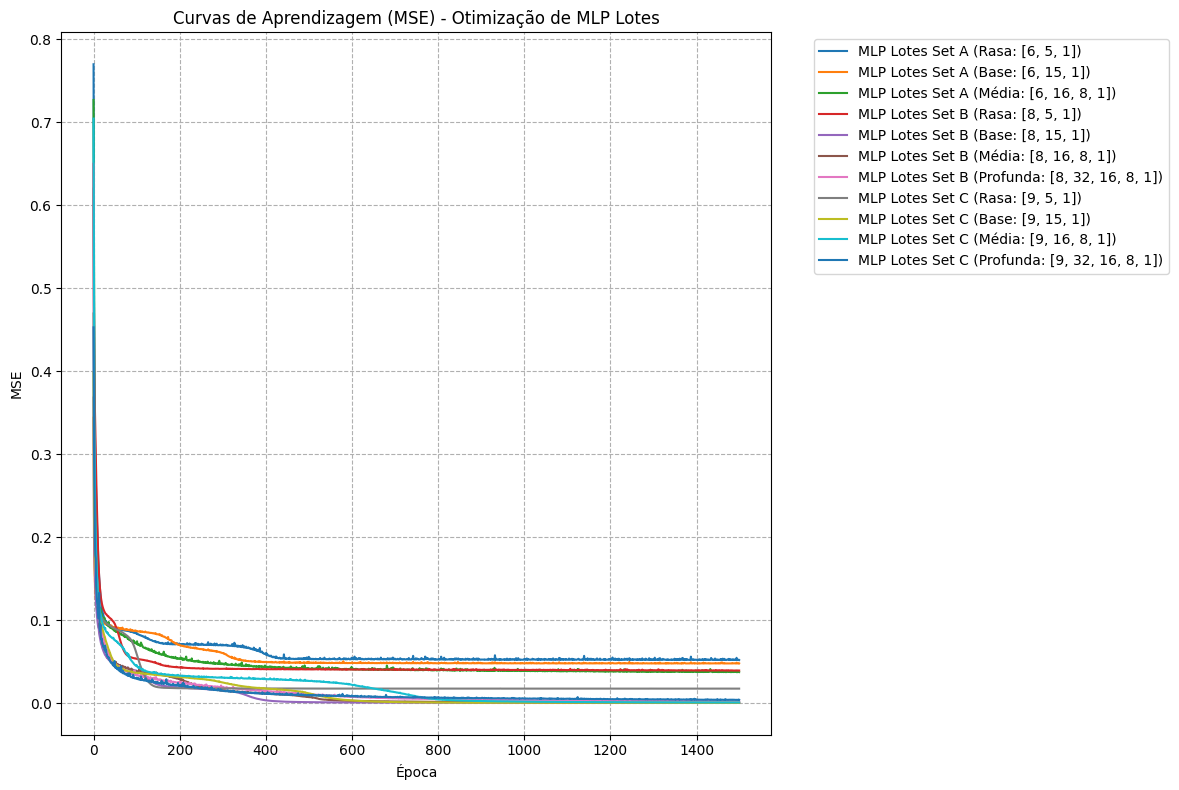

In [6]:
# ==================================================================
# BLOCO 6: Gráfico das Curvas de Aprendizado (Perda de MSE)
# ==================================================================
plt.figure(figsize=(12, 8))
for nome, hist in historicos.items():
    plt.plot(hist, label=nome, linewidth=1.5)
plt.title('Curvas de Aprendizagem (MSE) - Otimização de MLP Lotes')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [7]:
# ==================================================================
# BLOCO 7: Tabela Comparativa Geral (Leaderboard Final)
# ==================================================================
df_comparativo = pd.DataFrame(resultados_gerais)
df_comparativo = df_comparativo.sort_values(by=['Acurácia (%)', 'Precisão (%)'], ascending=[False, False])

# Formatação visual da tabela
df_formatado = df_comparativo.copy()
df_formatado['Acurácia (%)'] = df_formatado['Acurácia (%)'].apply("{:.2f}%".format)
df_formatado['Precisão (%)'] = df_formatado['Precisão (%)'].apply("{:.2f}%".format)
df_formatado['EQM (Real)'] = df_formatado['EQM (Real)'].apply("$ {:,.2f}".format)
df_formatado['Tempo de Treino (s)'] = df_formatado['Tempo de Treino (s)'].apply("{:.4f}s".format)

print("="*110)
print("            LEADERBOARD GERAL: COMPARATIVO DE PERFORMANCE DO MLP LOTES OTIMIZADO")
print("="*110)
display(df_formatado)

            LEADERBOARD GERAL: COMPARATIVO DE PERFORMANCE DO MLP LOTES OTIMIZADO


,Modelo,Épocas,Camadas Ocultas,Neurônios (Ocultos),Acurácia (%),Precisão (%),EQM (Real),Tempo de Treino (s)
8,MLP Lotes Set C (Base),1500,1 camada(s),15 neurônios,100.00%,99.68%,$ 912.81,18.7742s
4,MLP Lotes Set B (Base),1500,1 camada(s),15 neurônios,99.50%,99.69%,$ 885.09,14.6437s
5,MLP Lotes Set B (Média),1500,2 camada(s),"16, 8 neurônios",99.50%,99.43%,"$ 4,065.73",24.3546s
9,MLP Lotes Set C (Média),1500,2 camada(s),"16, 8 neurônios",99.50%,98.95%,"$ 12,280.48",26.0608s
6,MLP Lotes Set B (Profunda),1500,3 camada(s),"32, 16, 8 neurônios",95.50%,96.21%,"$ 188,038.53",38.8908s
7,MLP Lotes Set C (Rasa),1500,1 camada(s),5 neurônios,89.00%,95.49%,"$ 179,159.05",17.7414s
10,MLP Lotes Set C (Profunda),1500,3 camada(s),"32, 16, 8 neurônios",81.00%,93.68%,"$ 402,090.63",34.8187s
3,MLP Lotes Set B (Rasa),1500,1 camada(s),5 neurônios,77.00%,92.73%,"$ 436,030.67",12.7502s
0,MLP Lotes Set A (Rasa),1500,1 camada(s),5 neurônios,73.50%,91.66%,"$ 529,840.65",13.4063s
1,MLP Lotes Set A (Base),1500,1 camada(s),15 neurônios,72.00%,91.66%,"$ 571,876.24",13.7323s
